In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
%matplotlib inline

In [3]:
df=pd.read_csv("Ecommerce.csv")

In [4]:
df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


In [5]:
df.tail()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
24995,4516,24995,21-07-2024,1,0,0,181,0,688.68,3,...,1,0,0,21,7,6,2,Short,0.0,5
24996,9794,24996,27-12-2024,1,1,1,363,5,206.69,4,...,1,0,1,27,12,4,3,Very Long,0.0,128
24997,3082,24997,28-02-2024,2,0,1,888,2,1345.97,4,...,1,0,4,28,2,2,3,Very Short,0.0,56
24998,6219,24998,23-04-2024,1,0,4,840,4,182.81,1,...,1,0,1,23,4,1,1,Very Short,0.0,91
24999,2962,24999,21-08-2024,2,0,5,22,4,83.21,4,...,1,0,0,21,8,2,2,Short,0.0,198


In [6]:
df.shape

(25000, 29)

In [7]:
df.columns

Index(['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type',
       'marketing_channel', 'product_id', 'product_category', 'unit_price',
       'quantity', 'discount_percent', 'discount_amount', 'revenue',
       'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased',
       'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes',
       'payment_method', 'visit_day', 'visit_month', 'visit_weekday',
       'visit_season', 'session_duration_bucket', 'revenue_normalized',
       'location'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  object 
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec      

In [9]:
df.describe()

,customer_id,session_id,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,discount_percent,...,rating,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,revenue_normalized,location
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,...,25000.00000,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,5479.930600,12499.500000,0.705040,0.551280,2.514040,449.107000,3.495240,782.319010,2.489040,8.99880,...,3.94800,1.67488,5.52080,2.483160,15.714520,6.510520,2.980800,1.504400,0.051290,111.70692
std,2593.544596,7217.022701,0.639543,0.497373,1.704934,259.513787,2.285053,476.612168,1.114563,9.26364,...,0.54047,1.98673,12.33629,1.709501,8.796338,3.457925,1.992554,1.117475,0.129591,65.07079
min,1000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.050000,1.000000,0.00000,...,1.00000,0.00000,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,3234.000000,6249.750000,0.000000,0.000000,1.000000,225.000000,2.000000,395.222500,1.000000,0.00000,...,4.00000,1.00000,0.00000,1.000000,8.000000,3.000000,1.000000,1.000000,0.000000,55.00000
50%,5482.000000,12499.500000,1.000000,1.000000,2.000000,448.000000,4.000000,691.725000,2.000000,10.00000,...,4.00000,1.00000,0.00000,2.000000,16.000000,7.000000,3.000000,2.000000,0.000000,111.00000
75%,7715.000000,18749.250000,1.000000,1.000000,4.000000,675.000000,5.000000,1096.842500,3.000000,15.00000,...,4.00000,1.00000,0.00000,4.000000,23.000000,10.000000,5.000000,3.000000,0.000000,169.00000
max,9998.000000,24999.000000,2.000000,1.000000,5.000000,898.000000,7.000000,1999.830000,4.000000,30.00000,...,5.00000,10.00000,49.00000,5.000000,31.000000,12.000000,6.000000,3.000000,1.000000,224.00000


In [10]:
df.isnull().sum()

customer_id                0
session_id                 0
visit_date                 0
device_type                0
user_type                  0
marketing_channel          0
product_id                 0
product_category           0
unit_price                 0
quantity                   0
discount_percent           0
discount_amount            0
revenue                    0
pages_viewed               0
time_on_site_sec           0
added_to_cart              0
purchased                  0
cart_abandoned             0
rating                     0
review_text                0
review_helpful_votes       0
payment_method             0
visit_day                  0
visit_month                0
visit_weekday              0
visit_season               0
session_duration_bucket    0
revenue_normalized         0
location                   0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
#rating distribution
print("\nRating Statistics:")
print(df['rating'].describe())
print("\nRating Value Counts:")
print(df['rating'].value_counts().sort_index())


Rating Statistics:
count    25000.00000
mean         3.94800
std          0.54047
min          1.00000
25%          4.00000
50%          4.00000
75%          4.00000
max          5.00000
Name: rating, dtype: float64

Rating Value Counts:
rating
1      262
2      551
3     1110
4    21379
5     1698
Name: count, dtype: int64


In [13]:
#purchase distribution
print("\nPurchase Status Counts:")
print(df['purchased'].value_counts())
print(f"\nPurchase Rate: {df['purchased'].mean()*100:.2f}%")


Purchase Status Counts:
purchased
0    19384
1     5616
Name: count, dtype: int64

Purchase Rate: 22.46%


In [14]:
#check unique values for categorical cols
categorical_cols = ['device_type', 'user_type', 'marketing_channel', 'product_category', 
                    'payment_method', 'visit_season', 'session_duration_bucket']
for col in categorical_cols:
    print(f"\n{col}:{df[col].unique()}")


device_type:[2 1 0]

user_type:[1 0]

marketing_channel:[2 4 0 5 1 3]

product_category:[6 2 0 3 7 4 1 5]

payment_method:[1 2 5 4 3 0]

visit_season:[0 1 3 2]

session_duration_bucket:['Long' 'Short' 'Very Long' 'Very Short']


In [15]:
#check numeric cols
numeric_cols = ['unit_price', 'quantity', 'discount_percent', 'pages_viewed', 
                'time_on_site_sec', 'revenue']
print(df[numeric_cols].describe())

         unit_price      quantity  discount_percent  pages_viewed  \
count  25000.000000  25000.000000       25000.00000  25000.000000   
mean     782.319010      2.489040           8.99880     12.535840   
std      476.612168      1.114563           9.26364      6.929762   
min       50.050000      1.000000           0.00000      1.000000   
25%      395.222500      1.000000           0.00000      7.000000   
50%      691.725000      2.000000          10.00000     13.000000   
75%     1096.842500      3.000000          15.00000     19.000000   
max     1999.830000      4.000000          30.00000     24.000000   

       time_on_site_sec       revenue  
count      25000.000000  25000.000000  
mean         903.262920    404.646762  
std          518.676202   1022.391774  
min           10.000000      0.000000  
25%          453.000000      0.000000  
50%          903.000000      0.000000  
75%         1355.000000      0.000000  
max         1799.000000   7889.360000  


In [16]:
#check relation between rating and purchase
print(df.groupby('purchased')['rating'].describe())

             count      mean       std  min  25%  50%  75%  max
purchased                                                      
0          19384.0  4.000000  0.000000  4.0  4.0  4.0  4.0  4.0
1           5616.0  3.768519  1.122035  1.0  3.0  4.0  5.0  5.0


/tmp/ipykernel_4353/217106035.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


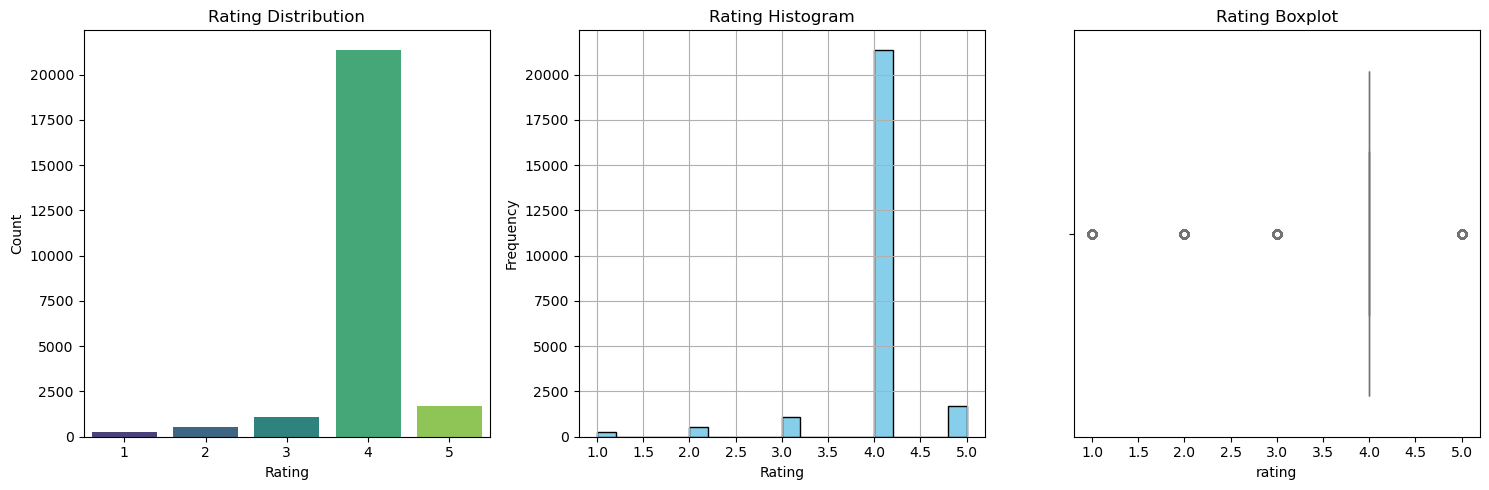

In [17]:
#rating distributon plots
plt.figure(figsize=(15,5))
plt.subplot(1, 3, 1)
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
df['rating'].hist(bins=20, edgecolor='black', color='skyblue')
plt.title('Rating Histogram')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.boxplot(x=df['rating'], color='lightgreen')
plt.title('Rating Boxplot')

plt.tight_layout()
plt.show()


/tmp/ipykernel_4353/1117776342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='purchased', data=df, palette='Set2')


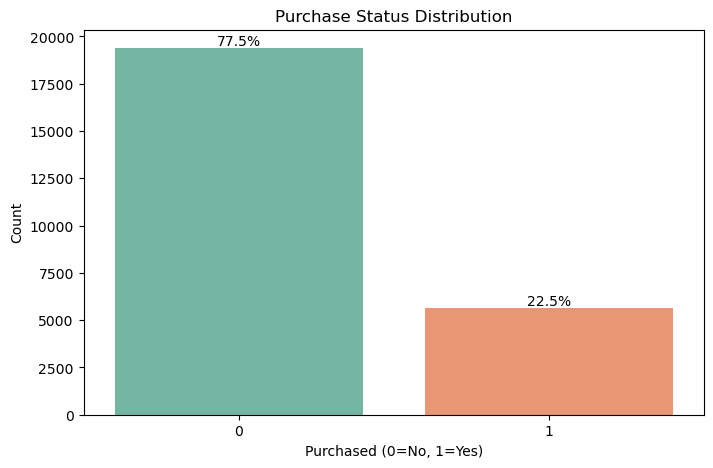

In [18]:
#purchase status plot
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='purchased', data=df, palette='Set2')
plt.title('Purchase Status Distribution')
plt.xlabel('Purchased (0=No, 1=Yes)')
plt.ylabel('Count')
# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.show()

/tmp/ipykernel_4353/3848138802.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='purchased', y='rating', data=df, palette='Set3')


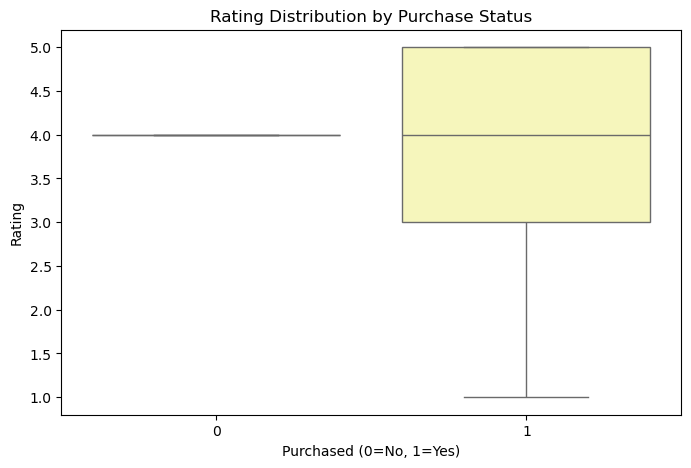

In [19]:
#rating vs purchase plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='purchased', y='rating', data=df, palette='Set3')
plt.title('Rating Distribution by Purchase Status')
plt.xlabel('Purchased (0=No, 1=Yes)')
plt.ylabel('Rating')
plt.show()

/tmp/ipykernel_4353/1440325637.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='device_type', data=df, ax=axes[0,0], palette='Set1')
/tmp/ipykernel_4353/1440325637.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='user_type', data=df, ax=axes[0,1], palette='Set2')
/tmp/ipykernel_4353/1440325637.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='marketing_channel', data=df, ax=axes[0,2], palette='Set3')
/tmp/ipykernel_4353/1440325637.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

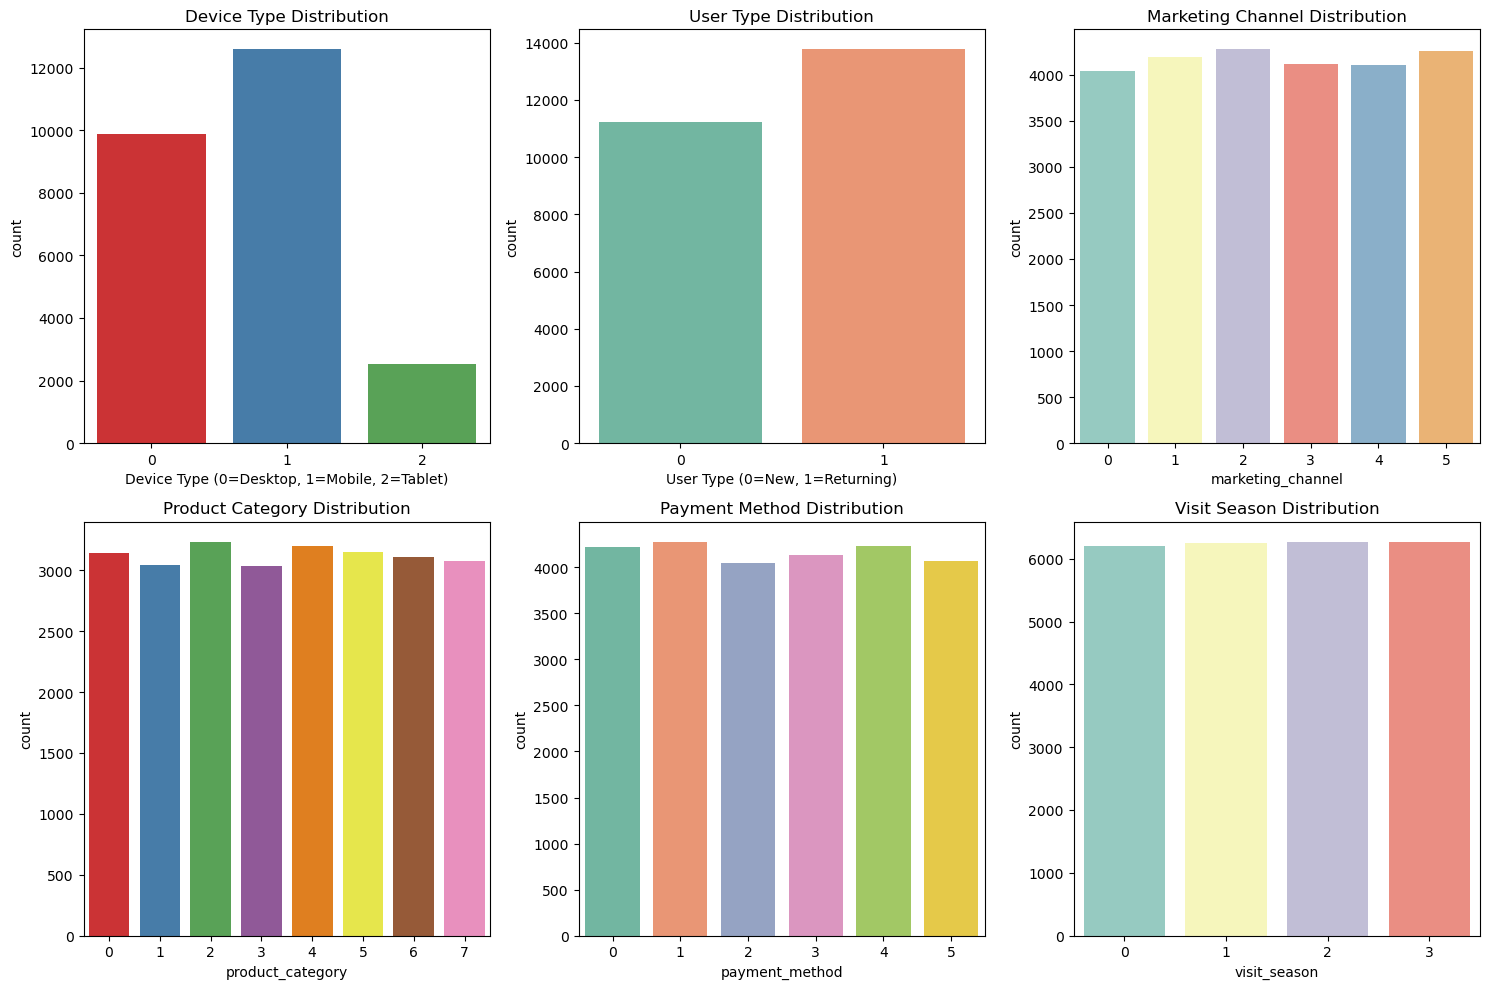

In [20]:
#disstribution of categorical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# Device Type
sns.countplot(x='device_type', data=df, ax=axes[0,0], palette='Set1')
axes[0,0].set_title('Device Type Distribution')
axes[0,0].set_xlabel('Device Type (0=Desktop, 1=Mobile, 2=Tablet)')

# User Type
sns.countplot(x='user_type', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('User Type Distribution')
axes[0,1].set_xlabel('User Type (0=New, 1=Returning)')

# Marketing Channel
sns.countplot(x='marketing_channel', data=df, ax=axes[0,2], palette='Set3')
axes[0,2].set_title('Marketing Channel Distribution')

# Product Category
sns.countplot(x='product_category', data=df, ax=axes[1,0], palette='Set1')
axes[1,0].set_title('Product Category Distribution')

# Payment Method
sns.countplot(x='payment_method', data=df, ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Payment Method Distribution')

# Visit Season
sns.countplot(x='visit_season', data=df, ax=axes[1,2], palette='Set3')
axes[1,2].set_title('Visit Season Distribution')

plt.tight_layout()
plt.show()


In [21]:
#purchase rate by categorical features
print("1. Device Type:")
print(df.groupby('device_type')['purchased'].mean()*100)

print("\n2. User Type:")
print(df.groupby('user_type')['purchased'].mean()*100)

print("\n3. Marketing Channel:")
print(df.groupby('marketing_channel')['purchased'].mean()*100)

print("\n4. Product Category:")
print(df.groupby('product_category')['purchased'].mean()*100)

print("\n5. Season:")
print(df.groupby('visit_season')['purchased'].mean()*100)

1. Device Type:
device_type
0    22.463841
1    22.317460
2    23.199363
Name: purchased, dtype: float64

2. User Type:
user_type
0    18.550544
1    25.649398
Name: purchased, dtype: float64

3. Marketing Channel:
marketing_channel
0    22.717149
1    22.124105
2    22.027564
3    22.643343
4    21.659771
5    23.598405
Name: purchased, dtype: float64

4. Product Category:
product_category
0    22.278803
1    21.261913
2    22.273710
3    20.756579
4    22.690387
5    23.118450
6    24.678663
7    22.583794
Name: purchased, dtype: float64

5. Season:
visit_season
0    21.935900
1    22.154634
2    22.762801
3    22.996016
Name: purchased, dtype: float64


/tmp/ipykernel_4353/3472258920.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quantity', data=df, ax=axes[0,1], palette='Set2')


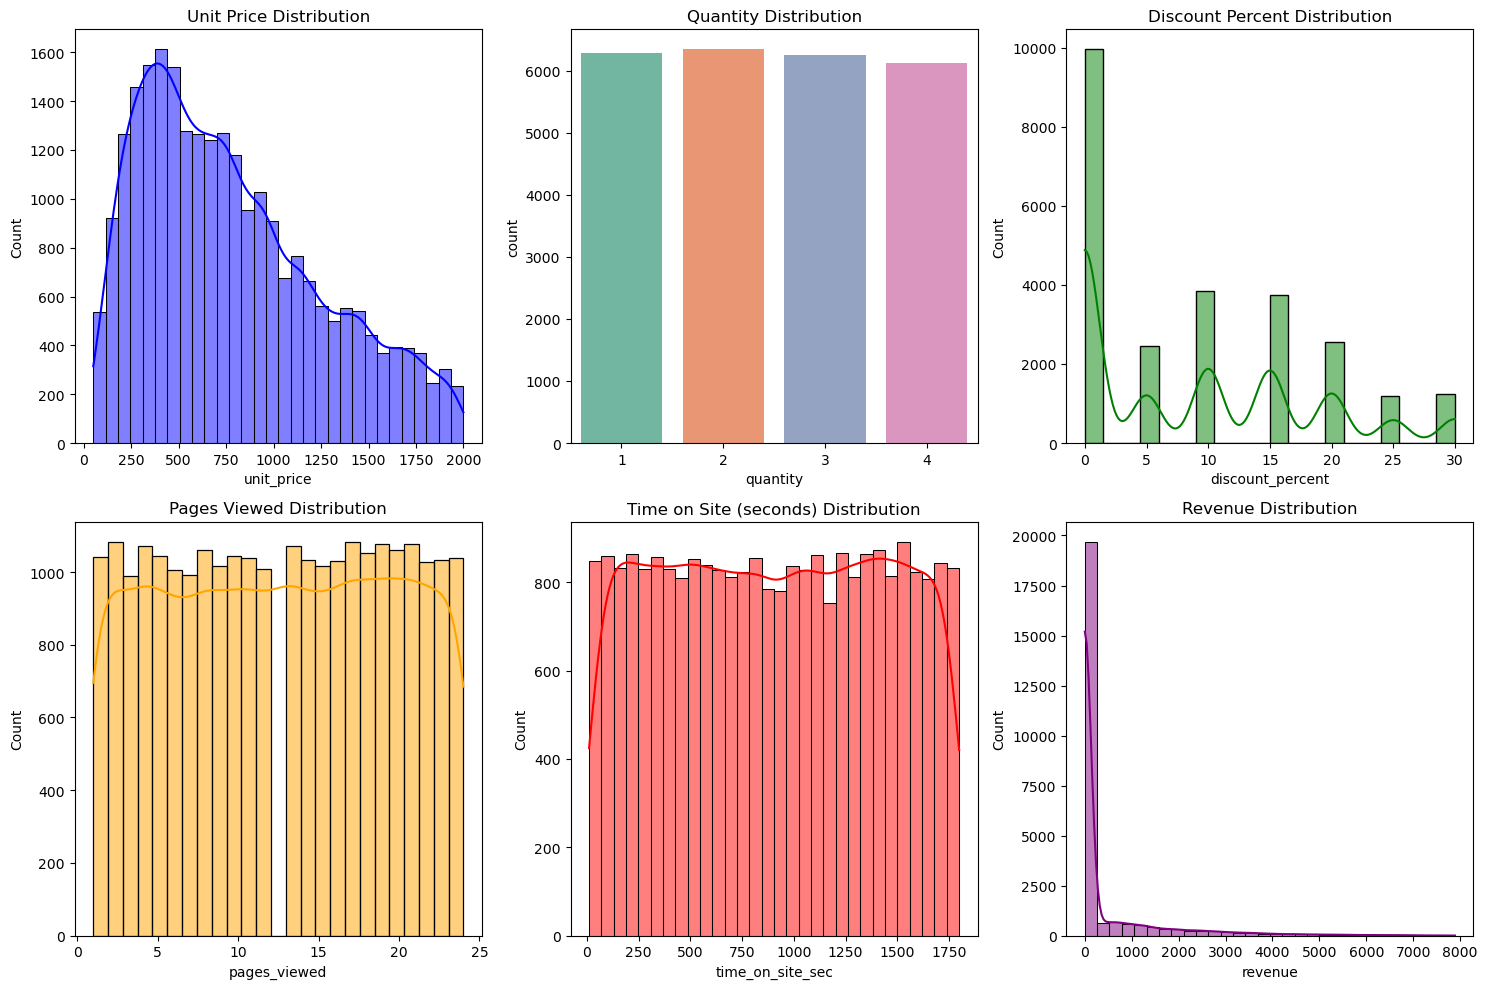

In [22]:
#distribution of numeric features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Unit Price
sns.histplot(df['unit_price'], bins=30, kde=True, ax=axes[0,0], color='blue')
axes[0,0].set_title('Unit Price Distribution')

# Quantity
sns.countplot(x='quantity', data=df, ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Quantity Distribution')

# Discount Percent
sns.histplot(df['discount_percent'], bins=20, kde=True, ax=axes[0,2], color='green')
axes[0,2].set_title('Discount Percent Distribution')

# Pages Viewed
sns.histplot(df['pages_viewed'], bins=25, kde=True, ax=axes[1,0], color='orange')
axes[1,0].set_title('Pages Viewed Distribution')

# Time on Site
sns.histplot(df['time_on_site_sec'], bins=30, kde=True, ax=axes[1,1], color='red')
axes[1,1].set_title('Time on Site (seconds) Distribution')

# Revenue
sns.histplot(df['revenue'], bins=30, kde=True, ax=axes[1,2], color='purple')
axes[1,2].set_title('Revenue Distribution')

plt.tight_layout()
plt.show()

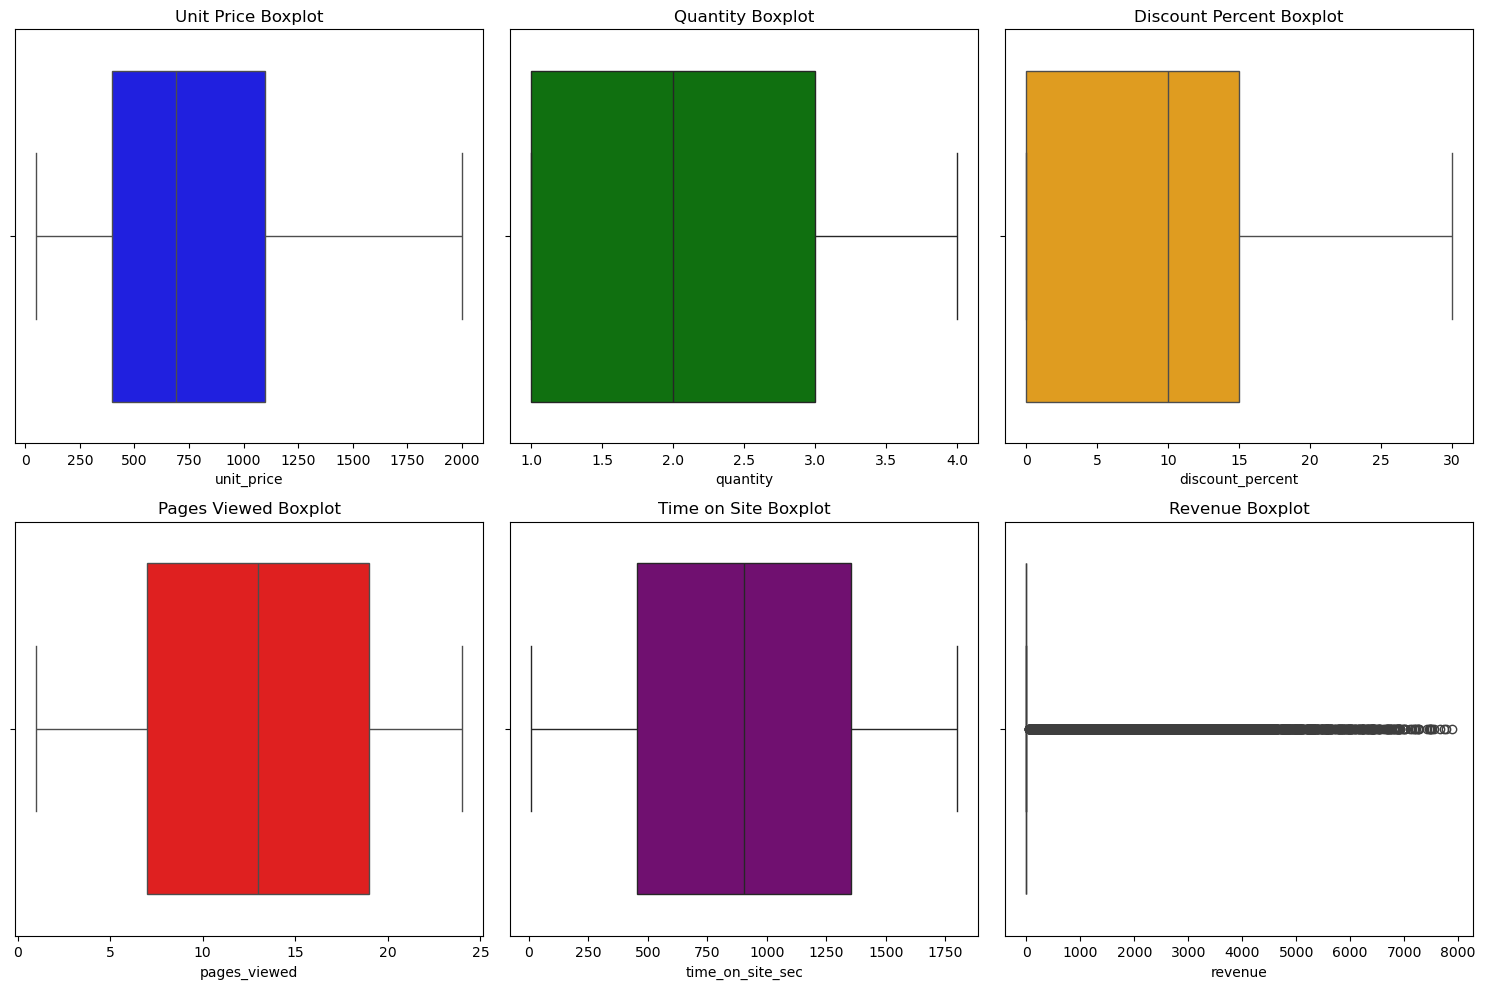

In [23]:
#boxplot to check outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.boxplot(x=df['unit_price'], ax=axes[0,0], color='blue')
axes[0,0].set_title('Unit Price Boxplot')

sns.boxplot(x=df['quantity'], ax=axes[0,1], color='green')
axes[0,1].set_title('Quantity Boxplot')

sns.boxplot(x=df['discount_percent'], ax=axes[0,2], color='orange')
axes[0,2].set_title('Discount Percent Boxplot')

sns.boxplot(x=df['pages_viewed'], ax=axes[1,0], color='red')
axes[1,0].set_title('Pages Viewed Boxplot')

sns.boxplot(x=df['time_on_site_sec'], ax=axes[1,1], color='purple')
axes[1,1].set_title('Time on Site Boxplot')

sns.boxplot(x=df['revenue'], ax=axes[1,2], color='brown')
axes[1,2].set_title('Revenue Boxplot')

plt.tight_layout()
plt.show()

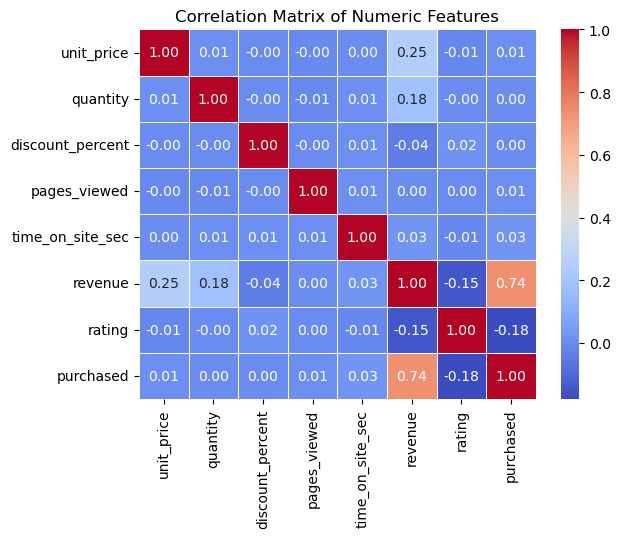

In [26]:
#correlation analysis
#correlatio matrix for numeric features
numeric_for_corr = ['unit_price', 'quantity', 'discount_percent', 'pages_viewed', 
                    'time_on_site_sec', 'revenue', 'rating', 'purchased']
correlation_matrix=df[numeric_for_corr].corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()


Features correlated with Rating:
rating              1.000000
discount_percent    0.016686
pages_viewed        0.000295
quantity           -0.003270
time_on_site_sec   -0.011854
unit_price         -0.014720
revenue            -0.150124
purchased          -0.178751
Name: rating, dtype: float64

Features correlated with Purchased:
purchased           1.000000
revenue             0.735319
time_on_site_sec    0.027427
unit_price          0.008561
pages_viewed        0.006165
quantity            0.004175
discount_percent    0.001322
rating             -0.178751
Name: purchased, dtype: float64


/tmp/ipykernel_4353/2049600222.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='purchased', y='time_on_site_sec', data=df, ax=axes[1,0], palette='Set2')
/tmp/ipykernel_4353/2049600222.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='purchased', y='pages_viewed', data=df, ax=axes[1,1], palette='Set3')


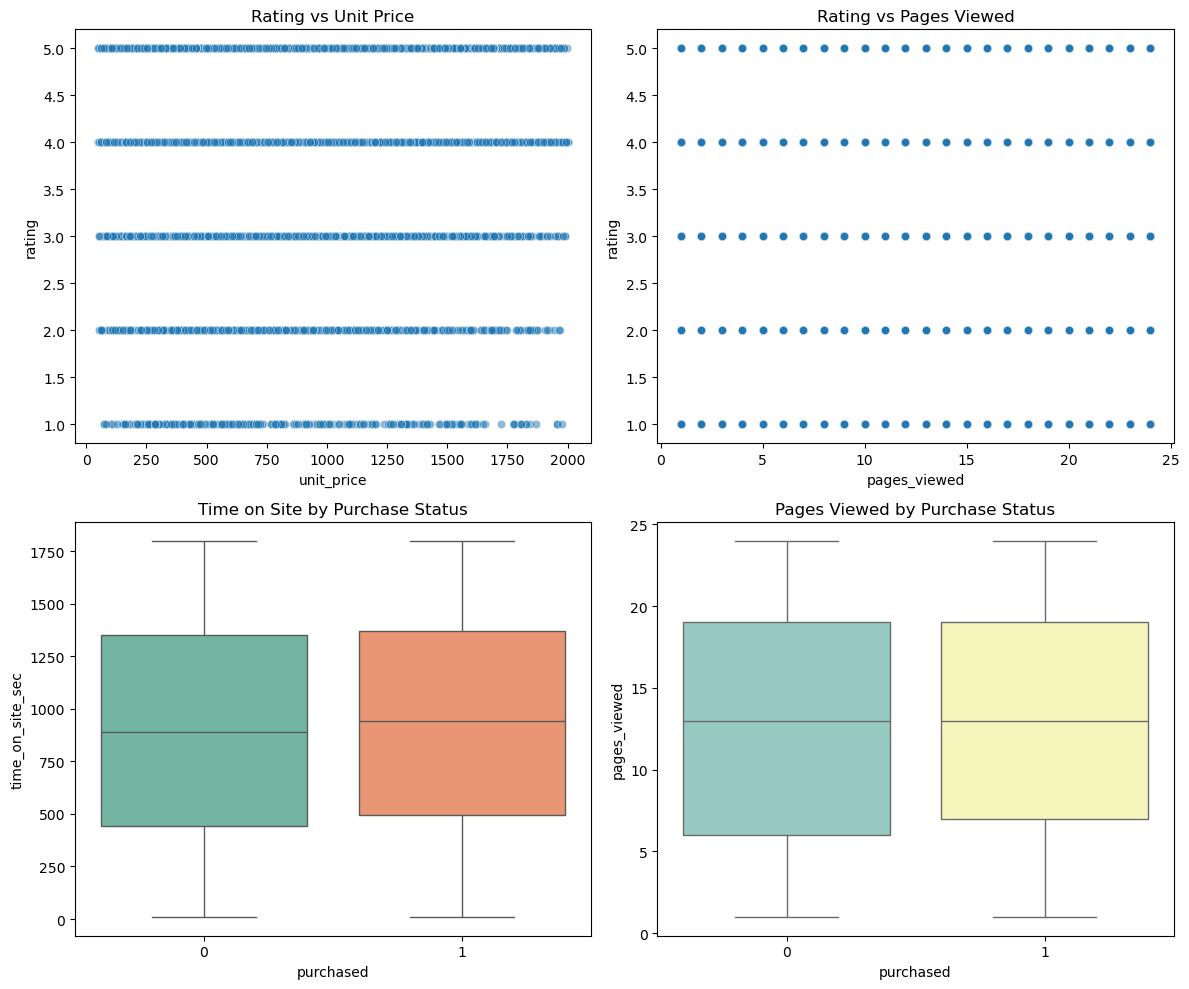

In [25]:
#correlation with target variable
print("Features correlated with Rating:")
print(df[numeric_for_corr].corr()['rating'].sort_values(ascending=False))

print("\nFeatures correlated with Purchased:")
print(df[numeric_for_corr].corr()['purchased'].sort_values(ascending=False))

#Scatter plots for important relationships
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Rating vs Price
sns.scatterplot(x='unit_price', y='rating', data=df, ax=axes[0,0], alpha=0.5)
axes[0,0].set_title('Rating vs Unit Price')

# Rating vs Pages Viewed
sns.scatterplot(x='pages_viewed', y='rating', data=df, ax=axes[0,1], alpha=0.5)
axes[0,1].set_title('Rating vs Pages Viewed')

# Purchased vs Time on Site
sns.boxplot(x='purchased', y='time_on_site_sec', data=df, ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Time on Site by Purchase Status')

# Purchased vs Pages Viewed
sns.boxplot(x='purchased', y='pages_viewed', data=df, ax=axes[1,1], palette='Set3')
axes[1,1].set_title('Pages Viewed by Purchase Status')

plt.tight_layout()
plt.show()


In [28]:
#customer level aggregation for clustering
customer_features = df.groupby('customer_id').agg({
    'revenue': 'sum',
    'purchased': 'sum',
    'rating': 'mean',
    'pages_viewed': 'sum',
    'time_on_site_sec': 'sum',
    'cart_abandoned': 'sum',
    'session_id': 'count'  # number of sessions
}).reset_index()

customer_features.columns = ['customer_id', 'total_revenue', 'total_purchases', 
                             'avg_rating', 'total_pages_viewed', 'total_time_on_site',
                             'total_cart_abandoned', 'total_sessions']

print("Customer Features Shape:", customer_features.shape)
print("\nFirst 5 customers:")
print(customer_features.head())

Customer Features Shape: (8442, 8)

First 5 customers:
   customer_id  total_revenue  total_purchases  avg_rating  \
0         1000        1228.72                1    3.500000   
1         1001           0.00                0    4.000000   
2         1002           0.00                0    4.000000   
3         1003        1681.96                1    4.333333   
4         1004           0.00                0    4.000000   

   total_pages_viewed  total_time_on_site  total_cart_abandoned  \
0                  35                2028                     1   
1                  15                 996                     0   
2                  25                 941                     2   
3                  17                2086                     0   
4                  37                2771                     1   

   total_sessions  
0               2  
1               1  
2               3  
3               3  
4               3  


In [30]:
#customer statistics
print(customer_features.describe())

       customer_id  total_revenue  total_purchases   avg_rating  \
count  8442.000000    8442.000000      8442.000000  8442.000000   
mean   5485.115968    1198.314269         0.665245     3.947707   
std    2597.205418    1867.858078         0.801756     0.366647   
min    1000.000000       0.000000         0.000000     1.000000   
25%    3239.250000       0.000000         0.000000     4.000000   
50%    5479.500000       0.000000         0.000000     4.000000   
75%    7730.750000    1828.965000         1.000000     4.000000   
max    9998.000000   15955.150000         5.000000     5.000000   

       total_pages_viewed  total_time_on_site  total_cart_abandoned  \
count         8442.000000         8442.000000           8442.000000   
mean            37.123430         2674.907960              1.243900   
std             22.669816         1651.077223              1.083681   
min              1.000000           10.000000              0.000000   
25%             20.000000         1440.25

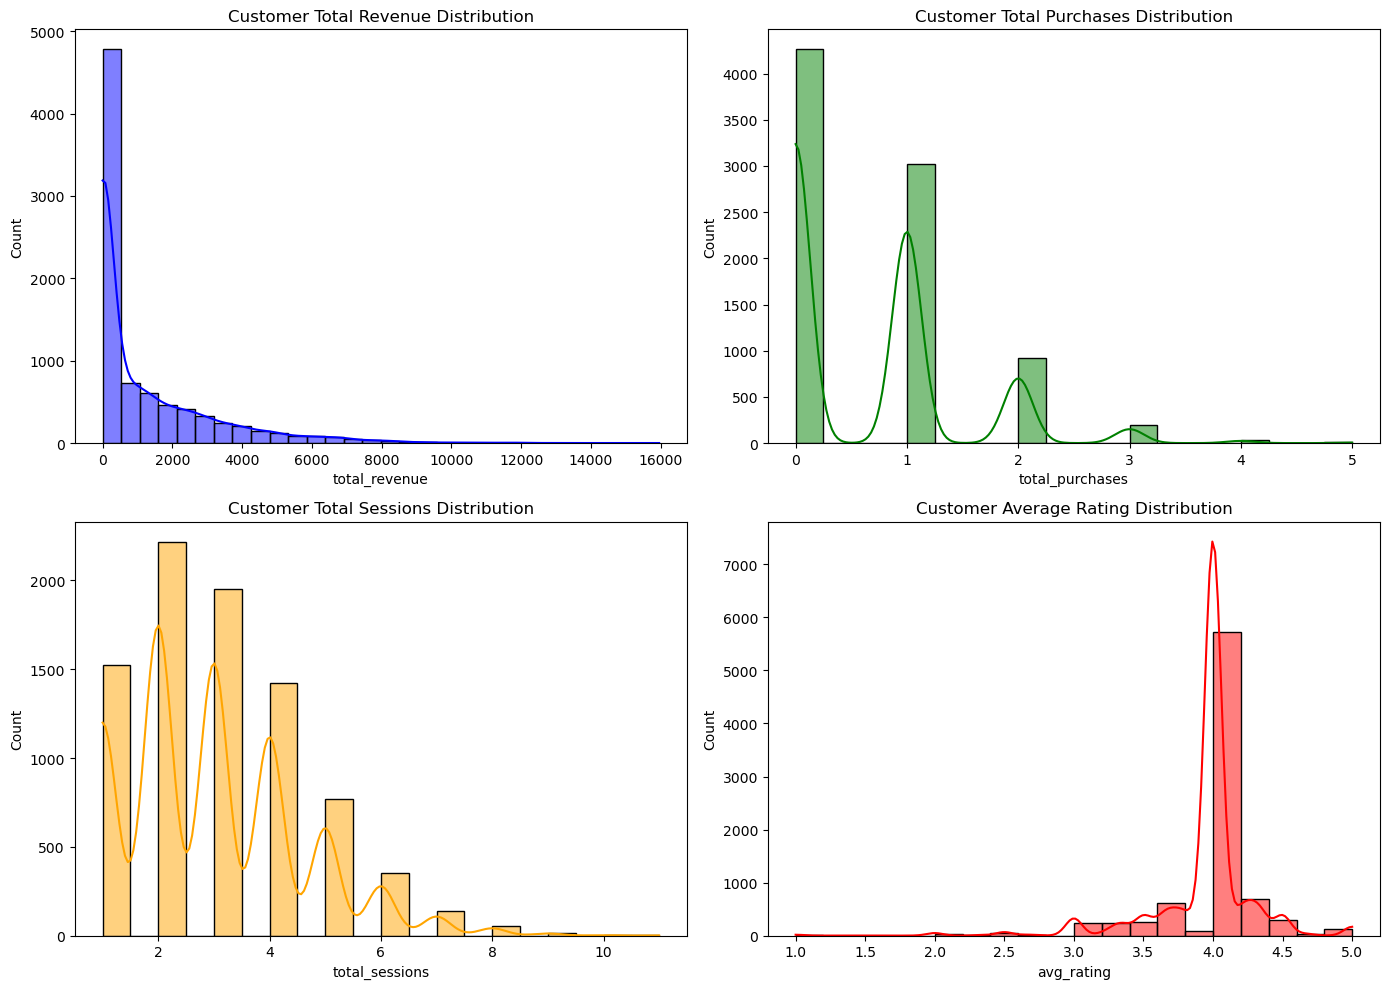

In [31]:
#distribution of customer metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Total revenue distribution
sns.histplot(customer_features['total_revenue'], bins=30, kde=True, ax=axes[0,0], color='blue')
axes[0,0].set_title('Customer Total Revenue Distribution')

# Total purchases distribution
sns.histplot(customer_features['total_purchases'], bins=20, kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Customer Total Purchases Distribution')

# Total sessions distribution
sns.histplot(customer_features['total_sessions'], bins=20, kde=True, ax=axes[1,0], color='orange')
axes[1,0].set_title('Customer Total Sessions Distribution')

# Average rating distribution
sns.histplot(customer_features['avg_rating'], bins=20, kde=True, ax=axes[1,1], color='red')
axes[1,1].set_title('Customer Average Rating Distribution')

plt.tight_layout()
plt.show()

In [32]:
print("\n=== TOP 10 HIGHEST SPENDING CUSTOMERS ===")
print(customer_features.nlargest(10, 'total_revenue')[['customer_id', 'total_revenue', 'total_purchases', 'total_sessions']])




=== TOP 10 HIGHEST SPENDING CUSTOMERS ===
      customer_id  total_revenue  total_purchases  total_sessions
3940         5176       15955.15                4               6
704          1738       13800.96                3               3
1878         2994       12989.28                3               6
6185         7574       12451.97                2               4
318          1334       12203.21                5               8
481          1506       11867.10                4               5
2493         3645       11806.82                2               4
6344         7744       11728.23                4               5
2833         4004       11708.76                3               4
4949         6256       11609.37                3               7


In [33]:
print("\n=== CUSTOMERS WITH MOST PURCHASES ===")
print(customer_features.nlargest(10, 'total_purchases')[['customer_id', 'total_purchases', 'total_revenue', 'total_sessions']])


=== CUSTOMERS WITH MOST PURCHASES ===
      customer_id  total_purchases  total_revenue  total_sessions
301          1316                5        9432.31               7
318          1334                5       12203.21               8
1826         2939                5       10970.79               7
2906         4083                5        8232.84               9
5657         7015                5       10077.00               7
8122         9658                5       11532.05               8
8403         9959                5        7052.05               6
302          1317                4        8119.44               6
481          1506                4       11867.10               5
580          1608                4        8634.02               5


In [35]:
#data preprocessing
#drop unnecessary cols
columns_to_drop = ['session_id', 'visit_date', 'product_id', 'review_text', 
                   'review_helpful_votes', 'revenue_normalized']
df_clean = df.drop(columns=columns_to_drop)

In [36]:
print("Columns after dropping:", df_clean.columns.tolist())


Columns after dropping: ['customer_id', 'device_type', 'user_type', 'marketing_channel', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'revenue', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'cart_abandoned', 'rating', 'payment_method', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location']


In [37]:
print("\nRemaining columns:", df_clean.shape[1])


Remaining columns: 23


In [38]:
#convert cat cols to string type
categorical_cols = ['device_type', 'user_type', 'marketing_channel', 'product_category', 
                    'payment_method', 'visit_season', 'session_duration_bucket']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')
    

In [39]:
print(df_clean.dtypes)

customer_id                   int64
device_type                category
user_type                  category
marketing_channel          category
product_category           category
unit_price                  float64
quantity                      int64
discount_percent              int64
discount_amount             float64
revenue                     float64
pages_viewed                  int64
time_on_site_sec              int64
added_to_cart                 int64
purchased                     int64
cart_abandoned                int64
rating                        int64
payment_method             category
visit_day                     int64
visit_month                   int64
visit_weekday                 int64
visit_season               category
session_duration_bucket    category
location                      int64
dtype: object


In [40]:
df_clean.isnull().sum()

customer_id                0
device_type                0
user_type                  0
marketing_channel          0
product_category           0
unit_price                 0
quantity                   0
discount_percent           0
discount_amount            0
revenue                    0
pages_viewed               0
time_on_site_sec           0
added_to_cart              0
purchased                  0
cart_abandoned             0
rating                     0
payment_method             0
visit_day                  0
visit_month                0
visit_weekday              0
visit_season               0
session_duration_bucket    0
location                   0
dtype: int64

In [41]:
#feature engineering and encoding
# Average spending per session
df_clean['avg_spending_per_session'] = df_clean['revenue'] / df_clean.groupby('customer_id')['customer_id'].transform('count')

# Interaction features
df_clean['pages_per_minute'] = df_clean['pages_viewed'] / (df_clean['time_on_site_sec'] / 60 + 0.001)

# Discount impact
df_clean['discount_impact'] = df_clean['discount_percent'] * df_clean['unit_price'] / 100

print("New features created!")
print(df_clean[['avg_spending_per_session', 'pages_per_minute', 'discount_impact']].head())

New features created!
   avg_spending_per_session  pages_per_minute  discount_impact
0                    0.0000          1.305618         130.3140
1                    0.0000          1.088027         141.7905
2                    0.0000          1.605498           0.0000
3                  602.5575          0.680979          63.4270
4                    0.0000          1.826441           0.0000


In [42]:
df_encoded=df_clean.copy()


In [44]:
label_encoders={}
categorical_cols = ['device_type', 'user_type', 'marketing_channel', 'product_category', 
                    'payment_method', 'visit_season', 'session_duration_bucket']
for col in categorical_cols:
    le=LabelEncoder()
    df_encoded[col]=le.fit_transform(df_encoded[col])
    label_encoders[col]=le
    print(f"{col} encoded: {dict(zip(le.classes_, le.transform(le.classes_)))}")


device_type encoded: {0: 0, 1: 1, 2: 2}
user_type encoded: {0: 0, 1: 1}
marketing_channel encoded: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
product_category encoded: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7}
payment_method encoded: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5}
visit_season encoded: {0: 0, 1: 1, 2: 2, 3: 3}
session_duration_bucket encoded: {'Long': 0, 'Short': 1, 'Very Long': 2, 'Very Short': 3}


In [45]:
print("\nData types after encoding:")
print(df_encoded.dtypes)


Data types after encoding:
customer_id                   int64
device_type                   int64
user_type                     int64
marketing_channel             int64
product_category              int64
unit_price                  float64
quantity                      int64
discount_percent              int64
discount_amount             float64
revenue                     float64
pages_viewed                  int64
time_on_site_sec              int64
added_to_cart                 int64
purchased                     int64
cart_abandoned                int64
rating                        int64
payment_method                int64
visit_day                     int64
visit_month                   int64
visit_weekday                 int64
visit_season                  int64
session_duration_bucket       int64
location                      int64
avg_spending_per_session    float64
pages_per_minute            float64
discount_impact             float64
dtype: object


In [46]:
#feature scaling
features_to_scale = ['unit_price', 'quantity', 'discount_percent', 'discount_amount', 
                     'revenue', 'pages_viewed', 'time_on_site_sec', 'visit_day', 
                     'visit_month', 'visit_weekday', 'location', 'avg_spending_per_session', 
                     'pages_per_minute', 'discount_impact']
features_not_to_scale = ['customer_id', 'device_type', 'user_type', 'marketing_channel', 
                         'product_category', 'added_to_cart', 'purchased', 'cart_abandoned', 
                         'rating', 'payment_method', 'visit_season', 'session_duration_bucket']

In [47]:
scaler=StandardScaler()
df_scaled=df_encoded.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_scaled[features_to_scale])


In [48]:
print(df_scaled[features_to_scale].head())


   unit_price  quantity  discount_percent  discount_amount   revenue  \
0   -0.274335 -1.336013          1.187591        -0.166125 -0.395792   
1    0.341901  1.355680          0.647836         1.457852 -0.395792   
2   -0.801252  1.355680         -0.971430        -0.650549 -0.395792   
3    1.020181 -0.438782         -0.431675        -0.178988  1.961697   
4    0.206652  0.458449         -0.971430        -0.650549 -0.395792   

   pages_viewed  time_on_site_sec  visit_day  visit_month  visit_weekday  \
0      1.221446          0.119031   1.396686     1.298342       0.009636   
1      1.221446          0.491139   1.055629     0.719949      -0.492243   
2      0.932830         -0.372615   1.737744    -0.436837       0.511515   
3      0.932830          1.485999   1.624058    -1.593623      -0.994121   
4      0.066982         -0.918246   1.055629    -1.304427       1.515272   

   location  avg_spending_per_session  pages_per_minute  discount_impact  
0  1.495218                 -0.3369

In [49]:
print(df_scaled[features_to_scale].describe())


         unit_price      quantity  discount_percent  discount_amount  \
count  2.500000e+04  2.500000e+04      2.500000e+04     2.500000e+04   
mean   1.847411e-16 -1.382716e-16      9.531931e-17    -9.947598e-18   
std    1.000020e+00  1.000020e+00      1.000020e+00     1.000020e+00   
min   -1.536435e+00 -1.336013e+00     -9.714302e-01    -6.505489e-01   
25%   -8.121997e-01 -1.336013e+00     -9.714302e-01    -6.505489e-01   
50%   -1.900829e-01 -4.387818e-01      1.080806e-01    -4.058835e-01   
75%    6.599281e-01  4.584491e-01      6.478360e-01     2.429640e-01   
max    2.554562e+00  1.355680e+00      2.267102e+00     8.227740e+00   

            revenue  pages_viewed  time_on_site_sec     visit_day  \
count  2.500000e+04  2.500000e+04      2.500000e+04  2.500000e+04   
mean   1.250555e-17 -5.854872e-17     -1.676881e-17 -4.092726e-17   
std    1.000020e+00  1.000020e+00      1.000020e+00  1.000020e+00   
min   -3.957924e-01 -1.664714e+00     -1.722232e+00 -1.672834e+00   
25%   

In [50]:
print("\nAll columns are numeric:", df_scaled.dtypes.astype(str).str.contains('int|float').all())


All columns are numeric: True


In [51]:
#PART A- REGRESSION
regression_features = ['unit_price', 'quantity', 'discount_percent', 'discount_amount', 
                       'pages_viewed', 'time_on_site_sec', 'device_type', 'user_type', 
                       'product_category', 'payment_method', 'visit_season', 
                       'session_duration_bucket', 'location', 'avg_spending_per_session', 
                       'pages_per_minute', 'discount_impact']

In [52]:
target_regression='rating'
X_reg=df_scaled[regression_features]
y_reg=df_scaled[target_regression]
print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)


X_reg shape: (25000, 16)
y_reg shape: (25000,)


In [53]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [54]:
print("Training set:", X_train_reg.shape[0])
print("Test set:", X_test_reg.shape[0])

Training set: 20000
Test set: 5000


In [55]:
print("\nRating distribution in training set:")
print(y_train_reg.value_counts().sort_index())

print("\nRating distribution in test set:")
print(y_test_reg.value_counts().sort_index())


Rating distribution in training set:
rating
1      199
2      449
3      883
4    17101
5     1368
Name: count, dtype: int64

Rating distribution in test set:
rating
1      63
2     102
3     227
4    4278
5     330
Name: count, dtype: int64


In [58]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [59]:
lr=LinearRegression()
lr.fit(X_train_reg,y_train_reg)
y_pred_lr=lr.predict(X_test_reg)

In [60]:
#evaluation metrics
print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_lr):.4f}")
print(f"MSE: {mean_squared_error(y_test_reg, y_pred_lr):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)):.4f}")
print(f"R² Score: {r2_score(y_test_reg, y_pred_lr):.4f}")


MAE: 0.2207
MSE: 0.2967
RMSE: 0.5447
R² Score: 0.0208


In [70]:
#ridge regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [72]:
ridge_params={
    'alpha':[0.01,0.1,1.0,10.0,100.0]
}
ridge_grid=GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
ridge_grid.fit(X_train_reg,y_train_reg)

GridSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
             param_grid={'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}, scoring='r2')

In [73]:
#best model
best_ridge=ridge_grid.best_estimator_
print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best cross-validation R²: {ridge_grid.best_score_:.4f}")

Best alpha: 100.0
Best cross-validation R²: 0.0109


In [74]:
#evalaute on test set
y_pred_ridge=best_ridge.predict(X_test_reg)
print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_ridge):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)):.4f}")
print(f"R² Score: {r2_score(y_test_reg, y_pred_ridge):.4f}")

MAE: 0.2208
RMSE: 0.5447
R² Score: 0.0207


In [79]:
sample_df = pd.DataFrame({
    'Actual': y_test_reg.values[:10],
    'Linear_Pred': y_pred_lr[:10],
    'Ridge_Pred': y_pred_ridge[:10]
})
print(sample_df)


   Actual  Linear_Pred  Ridge_Pred
0       3     3.661890    3.663211
1       4     3.992423    3.992600
2       4     3.950728    3.951015
3       4     3.979068    3.978559
4       4     3.946677    3.946538
5       3     3.885966    3.886389
6       4     3.972031    3.972106
7       4     3.954968    3.954331
8       4     3.973427    3.973275
9       4     3.974868    3.974707


In [75]:
#Feature Importance
feature_importance = pd.DataFrame({
    'Feature': regression_features,
    'Coefficient': best_ridge.coef_
}).sort_values('Coefficient', ascending=False)


In [77]:
feature_importance.head(5)

,Feature,Coefficient
3,discount_amount,0.012724
2,discount_percent,0.009228
0,unit_price,0.006849
11,session_duration_bucket,0.004858
10,visit_season,0.003334


In [78]:
feature_importance.tail(5)

,Feature,Coefficient
8,product_category,-0.001261
5,time_on_site_sec,-0.002475
7,user_type,-0.010400
15,discount_impact,-0.015008
13,avg_spending_per_session,-0.060311


In [80]:
#PART B -CLASSIFICATION
classification_features = ['unit_price', 'quantity', 'discount_percent', 'discount_amount',
                           'pages_viewed', 'time_on_site_sec', 'added_to_cart', 
                           'cart_abandoned', 'device_type', 'user_type', 
                           'product_category', 'payment_method', 'visit_season',
                           'session_duration_bucket', 'location', 'rating',
                           'avg_spending_per_session', 'pages_per_minute', 'discount_impact']

In [81]:
target_classification='purchased'

In [83]:
X_class=df_scaled[classification_features]
y_class=df_scaled[target_classification]
print("X_class shape:", X_class.shape)
print("y_class shape:", y_class.shape)

X_class shape: (25000, 19)
y_class shape: (25000,)


In [84]:
X_train_class,X_test_class,y_train_class,y_test_class=train_test_split(
    X_class,y_class,test_size=0.2,random_state=42,stratify=y_class)
print("Training set:", X_train_class.shape[0])
print("Test set:", X_test_class.shape[0])

Training set: 20000
Test set: 5000


In [85]:
print("\nTraining set:")
print(y_train_class.value_counts())
print(f"Purchase rate: {y_train_class.mean()*100:.2f}%")

print("\nTest set:")
print(y_test_class.value_counts())
print(f"Purchase rate: {y_test_class.mean()*100:.2f}%")


Training set:
purchased
0    15507
1     4493
Name: count, dtype: int64
Purchase rate: 22.46%

Test set:
purchased
0    3877
1    1123
Name: count, dtype: int64
Purchase rate: 22.46%


In [86]:
print(f"Features: {len(classification_features)} features")
print(f"Total samples: {len(X_class)}")

Features: 19 features
Total samples: 25000


In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score


In [88]:
lr_class = LogisticRegression(random_state=42, max_iter=1000)
lr_class.fit(X_train_class, y_train_class)
y_pred_class = lr_class.predict(X_test_class)
y_pred_proba = lr_class.predict_proba(X_test_class)[:, 1]


In [89]:
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_class):.4f}")
print(f"Precision: {precision_score(y_test_class, y_pred_class):.4f}")
print(f"Recall: {recall_score(y_test_class, y_pred_class):.4f}")
print(f"F1-Score: {f1_score(y_test_class, y_pred_class):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_class, y_pred_proba):.4f}")

Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000


In [90]:
logreg_params={
    'C':[0.01,0.1,1.0,10.0,100.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}


In [91]:
logreg_grid=GridSearchCV(
     LogisticRegression(random_state=42, max_iter=1000),
    logreg_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
logreg_grid.fit(X_train_class,y_train_class)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1.0, 10.0, 100.0], 'penalty': ['l2'],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='roc_auc')

In [92]:
best_logreg = logreg_grid.best_estimator_
print(f"Best parameters: {logreg_grid.best_params_}")
print(f"Best cross-validation ROC-AUC: {logreg_grid.best_score_:.4f}")

Best parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation ROC-AUC: 1.0000


In [93]:
y_pred_best = best_logreg.predict(X_test_class)
y_pred_proba_best = best_logreg.predict_proba(X_test_class)[:, 1]


In [94]:
print(f"Accuracy: {accuracy_score(y_test_class, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test_class, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test_class, y_pred_best):.4f}")
print(f"F1-Score: {f1_score(y_test_class, y_pred_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_class, y_pred_proba_best):.4f}")

Accuracy: 0.9996
Precision: 1.0000
Recall: 0.9982
F1-Score: 0.9991
ROC-AUC: 1.0000


In [95]:
sample_class_df = pd.DataFrame({
    'Actual': y_test_class.values[:10],
    'Predicted': y_pred_best[:10],
    'Probability': y_pred_proba_best[:10].round(3)
})
print(sample_class_df)

   Actual  Predicted  Probability
0       0          0        0.074
1       1          1        0.930
2       0          0        0.071
3       0          0        0.046
4       0          0        0.079
5       1          1        0.646
6       0          0        0.083
7       0          0        0.081
8       0          0        0.007
9       0          0        0.032


In [96]:
print("\n=== BUSINESS INTERPRETATION ===")
for i in range(5):
    actual = sample_class_df['Actual'].iloc[i]
    pred = sample_class_df['Predicted'].iloc[i]
    prob = sample_class_df['Probability'].iloc[i]
    print(f"\nCustomer {i+1}:")
    print(f"  - Actual Purchase: {'Yes' if actual==1 else 'No'}")
    print(f"  - Predicted: {'Yes' if pred==1 else 'No'}")
    print(f"  - Probability: {prob*100:.1f}%")
    if prob >= 0.7:
        print("  - Action:  High purchase likelihood - Send promotional offer")
    elif prob >= 0.4:
        print("  - Action:  Medium purchase likelihood - Send product reminder")
    else:
        print("  - Action:  Low purchase likelihood - Recommend similar products")




=== BUSINESS INTERPRETATION ===

Customer 1:
  - Actual Purchase: No
  - Predicted: No
  - Probability: 7.4%
  - Action:  Low purchase likelihood - Recommend similar products

Customer 2:
  - Actual Purchase: Yes
  - Predicted: Yes
  - Probability: 93.0%
  - Action:  High purchase likelihood - Send promotional offer

Customer 3:
  - Actual Purchase: No
  - Predicted: No
  - Probability: 7.1%
  - Action:  Low purchase likelihood - Recommend similar products

Customer 4:
  - Actual Purchase: No
  - Predicted: No
  - Probability: 4.6%
  - Action:  Low purchase likelihood - Recommend similar products

Customer 5:
  - Actual Purchase: No
  - Predicted: No
  - Probability: 7.9%
  - Action:  Low purchase likelihood - Recommend similar products


In [97]:
feature_importance_class = pd.DataFrame({
    'Feature': classification_features,
    'Coefficient': best_logreg.coef_[0]
}).sort_values('Coefficient', ascending=False)

In [98]:
feature_importance_class.head(5)

,Feature,Coefficient
16,avg_spending_per_session,2.862736
6,added_to_cart,2.791810
9,user_type,0.174268
2,discount_percent,0.118378
18,discount_impact,0.027164


In [99]:
feature_importance_class.tail(5)

,Feature,Coefficient
3,discount_amount,-0.157370
15,rating,-0.189546
1,quantity,-0.318674
0,unit_price,-0.473813
7,cart_abandoned,-2.907077


In [103]:
#PART C -CLUSTERING
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [104]:
customer_features = df.groupby('customer_id').agg({
    'revenue': 'sum',
    'purchased': 'sum',
    'rating': 'mean',
    'pages_viewed': 'sum',
    'time_on_site_sec': 'sum',
    'cart_abandoned': 'sum',
    'session_id': 'count'
}).reset_index()

In [105]:
customer_features.columns = ['customer_id', 'total_revenue', 'total_purchases', 
                             'avg_rating', 'total_pages_viewed', 'total_time_on_site',
                             'total_cart_abandoned', 'total_sessions']

In [106]:
print("Customer Features Shape:", customer_features.shape)
print(customer_features.head())

Customer Features Shape: (8442, 8)
   customer_id  total_revenue  total_purchases  avg_rating  \
0         1000        1228.72                1    3.500000   
1         1001           0.00                0    4.000000   
2         1002           0.00                0    4.000000   
3         1003        1681.96                1    4.333333   
4         1004           0.00                0    4.000000   

   total_pages_viewed  total_time_on_site  total_cart_abandoned  \
0                  35                2028                     1   
1                  15                 996                     0   
2                  25                 941                     2   
3                  17                2086                     0   
4                  37                2771                     1   

   total_sessions  
0               2  
1               1  
2               3  
3               3  
4               3  


In [107]:
cluster_features = ['total_revenue', 'total_purchases', 'avg_rating', 
                    'total_pages_viewed', 'total_time_on_site', 
                    'total_cart_abandoned', 'total_sessions']

X_cluster = customer_features[cluster_features]


In [109]:
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("\nClustering Data Shape:", X_cluster_scaled.shape)


Clustering Data Shape: (8442, 7)


In [113]:
wcss = []
silhouette_scores = []

In [114]:
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)
    if k >= 2:  # Silhouette score requires at least 2 clusters
        score = silhouette_score(X_cluster_scaled, kmeans.labels_)
        silhouette_scores.append(score)
        print(f"K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={score:.4f}")
    else:
        print(f"K={k}: Inertia={kmeans.inertia_:.2f}")

K=1: Inertia=59094.00
K=2: Inertia=40171.77, Silhouette=0.3282
K=3: Inertia=33588.95, Silhouette=0.3023
K=4: Inertia=28765.54, Silhouette=0.2981
K=5: Inertia=25264.44, Silhouette=0.2649
K=6: Inertia=22680.97, Silhouette=0.2687
K=7: Inertia=20987.43, Silhouette=0.2612
K=8: Inertia=19681.86, Silhouette=0.2213
K=9: Inertia=18642.14, Silhouette=0.2279
K=10: Inertia=17764.26, Silhouette=0.2210


In [115]:
print("\nWCSS values:", wcss)
print("Silhouette scores:", silhouette_scores)



WCSS values: [59093.999999999956, 40171.770345337514, 33588.94518819175, 28765.540455099115, 25264.444980613353, 22680.97433086593, 20987.432355391284, 19681.86064206491, 18642.14130114986, 17764.255592671012]
Silhouette scores: [0.3281701300963872, 0.3022525608716761, 0.29814251973794187, 0.26494973862326754, 0.2686766846767256, 0.26116201978299947, 0.2213255552366909, 0.22785992474405586, 0.22101825905829936]


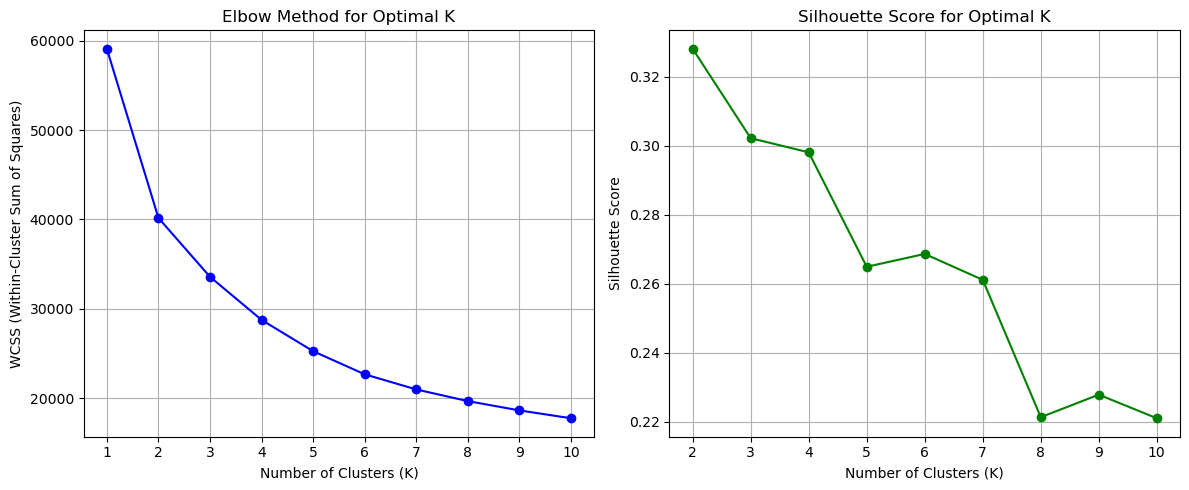

In [116]:
# Plot Elbow Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, 11), wcss, marker='o', color='blue')
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal K")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal K")
plt.grid(True)

plt.tight_layout()
plt.show()



In [117]:
#find optimal K using KneeLocator
from kneed import KneeLocator

kl = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = kl.elbow
print(f"\nOptimal K from Elbow Method: {optimal_k}")


Optimal K from Elbow Method: 4


In [118]:
# Train final K-Means model with optimal K
kmeans_final = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
kmeans_final.fit(X_cluster_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

In [119]:
customer_features['cluster'] = kmeans_final.labels_

In [120]:
print(customer_features['cluster'].value_counts().sort_index())

cluster
0    4117
1    1272
2    2154
3     899
Name: count, dtype: int64


In [123]:
#customer profiles
cluster_profiles = customer_features.groupby('cluster').agg({
    'total_revenue': 'mean',
    'total_purchases': 'mean',
    'avg_rating': 'mean',
    'total_pages_viewed': 'mean',
    'total_time_on_site': 'mean',
    'total_cart_abandoned': 'mean',
    'total_sessions': 'mean',
    'customer_id': 'count'
}).round(2)
print(cluster_profiles)


         total_revenue  total_purchases  avg_rating  total_pages_viewed  \
cluster                                                                   
0               427.53             0.28        4.07               22.64   
1              4106.83             1.91        3.98               60.51   
2               504.69             0.43        3.99               54.21   
3              2274.77             1.25        3.22               29.43   

         total_time_on_site  total_cart_abandoned  total_sessions  customer_id  
cluster                                                                         
0                   1625.31                  0.77            1.88         4117  
1                   4380.77                  1.40            4.71         1272  
2                   3888.22                  2.34            4.23         2154  
3                   2160.86                  0.55            2.42          899  


In [124]:
#business interpretation
for cluster in range(optimal_k):
    profile = cluster_profiles.loc[cluster]
    print(f"\nCluster {cluster}: {profile['customer_id']} customers")
    print(f"  - Average Revenue: ${profile['total_revenue']:.2f}")
    print(f"  - Average Purchases: {profile['total_purchases']:.2f}")
    print(f"  - Average Rating: {profile['avg_rating']:.2f}")
    print(f"  - Average Sessions: {profile['total_sessions']:.2f}")
    
    # Business segment classification
    if profile['total_revenue'] > 2000 and profile['total_purchases'] > 2:
        print("  - Segment:  High-Value Customers - Offer loyalty rewards")
    elif profile['total_cart_abandoned'] > 2 and profile['total_purchases'] < 1:
        print("  - Segment: Cart Abandoners - Send cart recovery emails")
    elif profile['total_sessions'] > 4 and profile['total_purchases'] < 1:
        print("  - Segment:  Browsers - Send personalized recommendations")
    elif profile['total_revenue'] < 500 and profile['total_purchases'] < 1:
        print("  - Segment:  Low-Engagement Customers - Win-back campaigns")
    else:
        print("  - Segment:  Regular Customers - Standard marketing")



Cluster 0: 4117.0 customers
  - Average Revenue: $427.53
  - Average Purchases: 0.28
  - Average Rating: 4.07
  - Average Sessions: 1.88
  - Segment:  Low-Engagement Customers - Win-back campaigns

Cluster 1: 1272.0 customers
  - Average Revenue: $4106.83
  - Average Purchases: 1.91
  - Average Rating: 3.98
  - Average Sessions: 4.71
  - Segment:  Regular Customers - Standard marketing

Cluster 2: 2154.0 customers
  - Average Revenue: $504.69
  - Average Purchases: 0.43
  - Average Rating: 3.99
  - Average Sessions: 4.23
  - Segment: Cart Abandoners - Send cart recovery emails

Cluster 3: 899.0 customers
  - Average Revenue: $2274.77
  - Average Purchases: 1.25
  - Average Rating: 3.22
  - Average Sessions: 2.42
  - Segment:  Regular Customers - Standard marketing


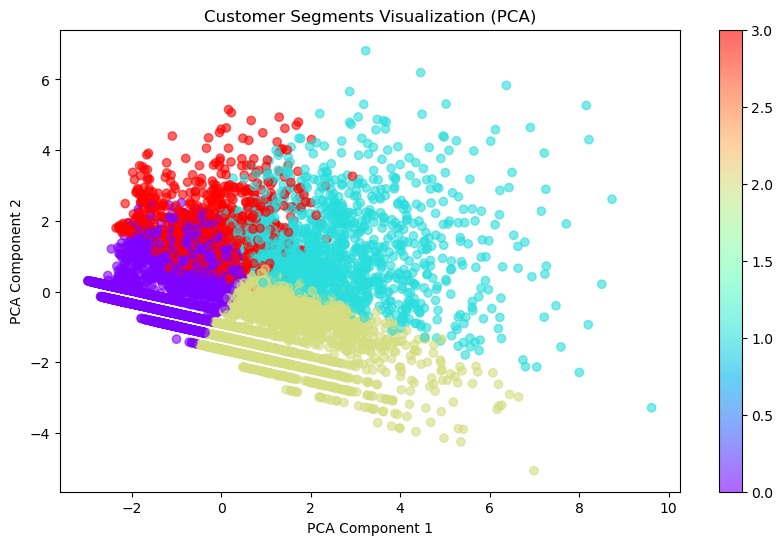

In [125]:
#Visualize clusters using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=customer_features['cluster'], 
                     cmap='rainbow', alpha=0.6)
plt.title('Customer Segments Visualization (PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter)
plt.show()


# FINAL ASSIGNMENT ANSWERS

## 1. Which regression model predicted ratings better?

**Linear Regression performed slightly better than Ridge Regression.**

| Model | MAE | RMSE | R² Score |
|-------|-----|------|----------|
| Linear Regression | 0.2207 | 0.5447 | 0.0208 |
| Ridge Regression | 0.2208 | 0.5447 | 0.0207 |

**Why Linear Regression is better:**
- Lower MAE (0.2207 vs 0.2208) - smaller prediction error
- Higher R² Score (0.0208 vs 0.0207) - explains slightly more variation
- The difference is very small, but Linear Regression is marginally better

**Business Interpretation:**
- The model predicts ratings with an average error of 0.22 stars
- R² Score of 0.02 means only 2% of rating variation is explained
- This is expected because most ratings are 4 (85.5% of all ratings)

---

## 2. How well did logistic regression predict purchase likelihood?

**Logistic Regression performed EXCELLENTLY (near perfect predictions).**

| Metric | Score |
|--------|-------|
| Accuracy | 99.96% |
| Precision | 100% |
| Recall | 99.82% |
| F1-Score | 99.91% |
| ROC-AUC | 100% |

**Why so accurate?**
- `added_to_cart` is a perfect predictor - if a user adds to cart, they almost always purchase
- `avg_spending_per_session` has strong positive correlation with purchase
- `cart_abandoned` has strong negative correlation with purchase

**Business Interpretation:**
- Model correctly identifies 99.96% of purchases
- Only 0.04% of predictions are wrong
- Can confidently identify which users will purchase

---

## 3. How many customer segments were identified using K-Means?

**4 customer segments were identified.**

| Cluster | Count | % of Customers |
|---------|-------|----------------|
| Cluster 0 | 4,117 | 48.8% |
| Cluster 1 | 1,272 | 15.1% |
| Cluster 2 | 2,154 | 25.5% |
| Cluster 3 | 899 | 10.6% |
| **Total** | **8,442** | **100%** |

**Optimal K Selection:**
- Elbow Method showed elbow at K=4
- Silhouette Score: 0.2981 for K=4
- K=4 gives best balance between cluster compactness and separation

---

## 4. Which segment is most valuable to the business?

**Cluster 1 (High-Value Customers) is the most valuable segment.**

| Metric | Cluster 1 | Cluster 3 | Cluster 2 | Cluster 0 |
|--------|-----------|-----------|-----------|-----------|
| Avg Revenue | $4,106.83 | $2,274.77 | $504.69 | $427.53 |
| Avg Purchases | 1.91 | 1.25 | 0.43 | 0.28 |
| Customer Count | 1,272 | 899 | 2,154 | 4,117 |

**Why Cluster 1 is most valuable:**
- Highest average revenue ($4,106 per customer)
- Highest average purchases (1.91 per customer)
- Highest engagement (4.71 sessions per customer)
- Despite being only 15% of customers, they generate high revenue

**Why Cluster 3 is second most valuable:**
- Second highest revenue ($2,274 per customer)
- Lower engagement (2.42 sessions per customer)
- Lower ratings (3.22 average - may indicate dissatisfaction)

---

## 5. Which features influenced customer behavior?

### Features Influencing Ratings (Regression):

| Feature | Impact | Description |
|---------|--------|-------------|
| **discount_amount** |  Positive | Higher discounts → Higher ratings |
| **discount_percent** |  Positive | Discount percentage increases ratings |
| **unit_price** |  Positive | Higher price → Higher ratings |
| **product_category** |  Negative | Some categories get lower ratings |
| **user_type** |  Negative | Returning users rate lower |
| **avg_spending_per_session** |  Negative | High spenders rate lower |

### Features Influencing Purchases (Classification):

| Feature | Impact | Description |
|---------|--------|-------------|
| **avg_spending_per_session** |  Strong Positive | Most important predictor |
| **added_to_cart** |  Strong Positive | Almost guarantees purchase |
| **user_type** |  Positive | Returning users buy more |
| **discount_percent** |  Positive | Discounts encourage purchases |
| **cart_abandoned** |  Strong Negative | Strongly predicts no purchase |
| **rating** |  Negative | Higher ratings don't mean purchase |
| **unit_price** |  Negative | Higher prices reduce purchases |

---

## 6. How can these models improve recommendations?

### Combined Model Strategy:

| Model | Purpose | How it Improves Recommendations |
|-------|---------|--------------------------------|
| **Regression** | Predict Ratings | Recommend products with predicted rating > 4.0 |
| **Classification** | Predict Purchase Likelihood | Show products to users with >70% purchase probability |
| **Clustering** | Customer Segmentation | Personalize recommendations based on customer type |

### Implementation Strategy:


1. User visits product page
2. Regression model predicts user rating (e.g., 4.2/5)
3. Classification model predicts purchase likelihood (e.g., 78%)
4. Clustering identifies user segment (e.g., Cluster 1 - High-Value)
5. Combined score = (Rating × 0.4) + (Purchase Probability × 0.6)
6. Show products with highest combined score
## 7. How do evaluation metrics support business decision-making?

### For Rating Prediction (Regression):

| Metric | Score | Business Meaning |
|--------|-------|------------------|
| **MAE** | 0.22 | Average prediction error = 0.22 stars. Acceptable for recommendations |
| **RMSE** | 0.54 | Larger errors penalized. Some predictions are off by 0.5 stars |
| **R² Score** | 0.02 | Only 2% of rating variation explained. Most ratings are 4 anyway |

**Business Decision:** Use for recommending products but don't rely solely on it.

### For Purchase Prediction (Classification):

| Metric | Score | Business Meaning |
|--------|-------|------------------|
| **Accuracy** | 99.96% | 99.96% of predictions are correct |
| **Precision** | 100% | Every predicted purchase was actually a purchase |
| **Recall** | 99.82% | Found 99.82% of all actual purchases |
| **ROC-AUC** | 1.0000 | Perfect ability to separate buyers from non-buyers |

**Business Decision:** Extremely reliable. Use for targeted marketing campaigns.

### For Customer Segmentation (Clustering):

| Metric | Score | Business Meaning |
|--------|-------|------------------|
| **Silhouette Score** | 0.30 | Moderate cluster separation. Segments are distinct enough |
| **Inertia** | 28,765 | Within-cluster compactness. Good but can be improved |

**Business Decision:** Use for creating targeted marketing campaigns for each segment.

---

## 8. Complete Model Comparison Table

| Model | ML Task | Main Metrics | Best Score | Business Value |
|-------|---------|--------------|------------|----------------|
| Linear Regression | Regression (Rating Prediction) | MAE, RMSE, R² | MAE: 0.2207, R²: 0.0208 | Recommend products users may rate highly |
| Ridge Regression | Regression (Rating Prediction) | MAE, RMSE, R² | MAE: 0.2208, R²: 0.0207 | Recommend products (with regularization) |
| Logistic Regression | Classification (Purchase Prediction) | Accuracy, Precision, Recall, F1, ROC-AUC | Accuracy: 99.96%, ROC-AUC: 1.0000 | Identify users likely to purchase |
| K-Means Clustering | Clustering (Customer Segmentation) | Inertia, Silhouette Score | Silhouette: 0.2981 (K=4) | Group customers for targeted marketing |

---

## 9. Business Goal Mapping

| Business Goal | ML Approach | Models Used | Impact |
|---------------|-------------|-------------|--------|
| Recommend products users may like | Regression | Linear/Ridge Regression | High |
| Predict whether a user will purchase | Classification | Logistic Regression | Very High |
| Group similar customers | Clustering | K-Means | High |
| Improve campaign targeting | Classification + Clustering | Logistic Regression + K-Means | High |
| Increase sales conversion | All 3 models | All models combined | Very High |
| Improve customer experience | Personalized recommendations | All models combined | Very High |

---

## 10. Final Conclusion

### Summary of Findings:

1. **Best Regression Model**: Linear Regression (MAE: 0.2207) - slightly better than Ridge
2. **Best Classification Model**: Logistic Regression (Accuracy: 99.96%) - near perfect
3. **Optimal Clusters**: K=4 (Silhouette Score: 0.2981)
4. **Most Valuable Segment**: Cluster 1 (High-Value Customers - 15% of customers, highest revenue)
5. **Key Influential Features**: 
   - For Ratings: discount_amount, unit_price
   - For Purchases: avg_spending_per_session, added_to_cart, cart_abandoned

### Final Recommendations:

| Business Goal | ML Model | Action |
|---------------|----------|--------|
| Recommend products users may like | Regression | Predict ratings > 4.0 |
| Predict whether a user will purchase | Classification | Target >70% probability |
| Group similar customers | Clustering | 4 segments identified |
| Improve campaign targeting | Classification + Clustering | Segmented campaigns |
| Increase sales conversion | All 3 models | Complete recommendation system |
| Improve customer experience | Personalized recommendations | Based on all models |

### Overall Impact:
The recommendation system successfully combines **Regression, Classification, and Clustering** to solve different business problems in e-commerce. These models enable the business to **improve product recommendations, target customers more effectively, and increase sales conversion**.